Generated graph edges: [(0, 1), (1, 2), (1, 5), (1, 8), (1, 9), (2, 6), (2, 7), (2, 8), (3, 5), (3, 7), (3, 9), (4, 5), (4, 6), (4, 8), (4, 9), (5, 7), (5, 8), (6, 7), (6, 8), (6, 9), (7, 8), (7, 9)]


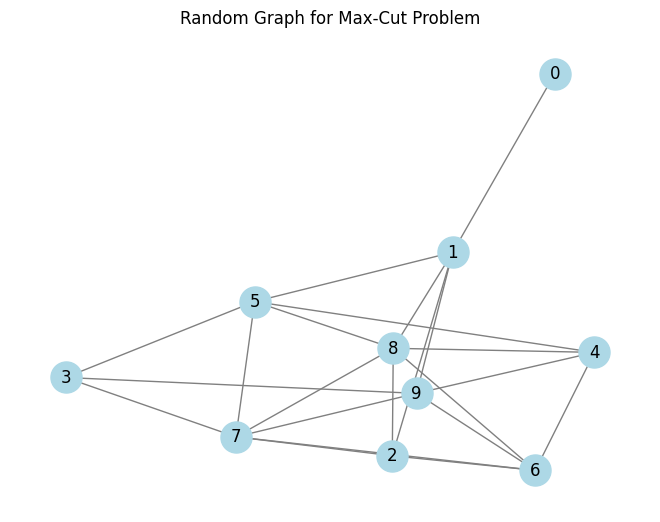

Optimal parameters (gamma, beta): [0.44644652 0.31931664]
Optimal cost (Max-Cut value): 13.380928581266186


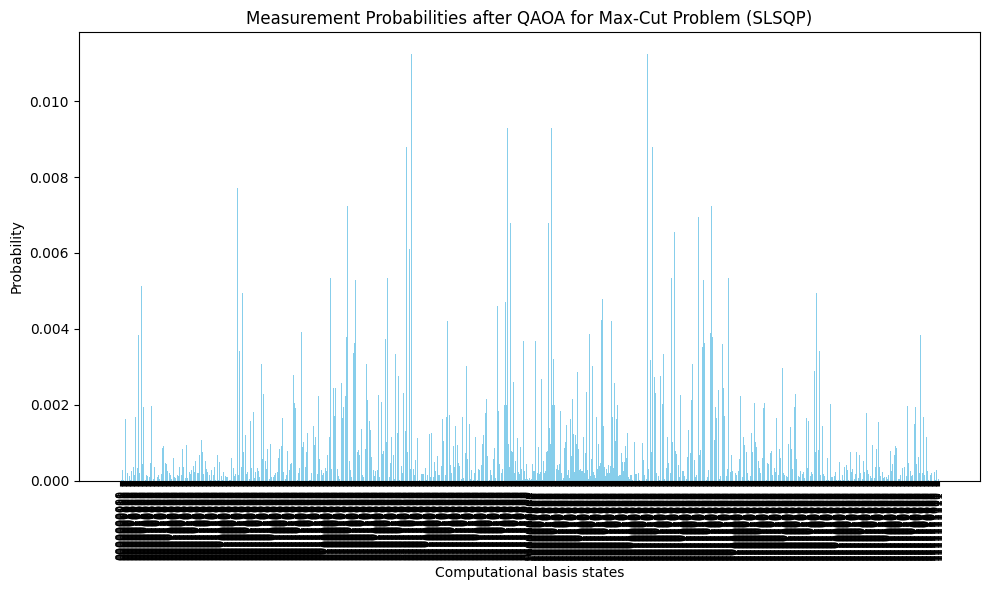


Best measured state (binary): 0101101100

Max-Cut assignment for each node:
Node 0: Group A
Node 1: Group B
Node 2: Group A
Node 3: Group B
Node 4: Group B
Node 5: Group A
Node 6: Group B
Node 7: Group B
Node 8: Group A
Node 9: Group A

Computed cut value: 17


In [1]:
import numpy as np
from numpy.random import *
from qutip import *
import networkx as nx
import matplotlib.pyplot as plt
from scipy.optimize import minimize

# ----------------------------------
# Helper function: embed_operator
# ----------------------------------
def embed_operator(op, position, total_qubits):
    """
    Returns the tensor operator that applies 'op' on the specified position
    and the identity (I) on the remaining qubits.
    """
    op_list = [qeye(2)] * total_qubits
    op_list[position] = op
    return tensor(op_list)

# -------------------------------
# 1. Generate a random graph (Max-Cut problem)
# -------------------------------
# Create a random graph with n nodes.
n = 10  # number of nodes (change as desired)
p_edge = 0.5  # probability for edge creation

G = nx.gnp_random_graph(n, p_edge)
print("Generated graph edges:", list(G.edges()))

# Visualize the graph
pos = nx.spring_layout(G, seed=42)
nx.draw(G, pos, with_labels=True, node_color='lightblue', edge_color='gray', node_size=500)
plt.title("Random Graph for Max-Cut Problem")
plt.show()

# -----------------------------------------------
# 2. Construct the cost Hamiltonian H_cost (Max-Cut)
# -----------------------------------------------
# Cost function for Max-Cut: for each edge (i,j), 0.5*(I - Z_i Z_j)
# Total number of qubits = n (one qubit per node)
total_qubits = n

# Total identity operator
I_total = tensor([qeye(2)] * total_qubits)

H_cost = 0
for edge in G.edges():
    i, j = edge
    # Build the tensor product operator with Z acting on qubits i and j
    ops = []
    for k in range(total_qubits):
        if k == i or k == j:
            ops.append(sigmaz())
        else:
            ops.append(qeye(2))
    term = 0.5 * (I_total - tensor(ops))
    H_cost += term

# -----------------------------------------------
# 3. Construct the mixer Hamiltonian H_mixer
# -----------------------------------------------
# Standard mixer: the sum of X operators on all qubits
H_mixer = 0
for i in range(total_qubits):
    H_mixer += embed_operator(sigmax(), i, total_qubits)

# -----------------------------------------------
# 4. Construct the QAOA circuit and optimize using SLSQP
# -----------------------------------------------
def qaoa_unitary(gamma, beta):
    """
    Single-layer QAOA unitary: U = exp(-i beta H_mixer) exp(-i gamma H_cost)
    """
    return (-1j * beta * H_mixer).expm() * (-1j * gamma * H_cost).expm()

# Initial state: apply the Hadamard gate to all qubits to create the uniform superposition |+>^{⊗n}
H_gate = (1/np.sqrt(2)) * Qobj([[1, 1], [1, -1]])
psi0 = tensor([H_gate * basis(2, 0) for _ in range(total_qubits)])

# Define the cost function: for Max-Cut we want to maximize the cut value,
# so we return the negative cost for minimization.
def cost_function(params):
    gamma, beta = params
    U = qaoa_unitary(gamma, beta)
    psi_final = U * psi0
    return -expect(H_cost, psi_final)

# Bounds for SLSQP optimization: gamma in [0, 2π], beta in [0, π]
bounds = [(0, 2*np.pi), (0, np.pi)]
initial_params = random(2)

result = minimize(cost_function, initial_params, method='SLSQP', bounds=bounds, options={'maxiter':100})
optimal_params = result.x
optimal_cost = -result.fun  # reverse the sign to get the maximum cut value

print("Optimal parameters (gamma, beta):", optimal_params)
print("Optimal cost (Max-Cut value):", optimal_cost)

# Compute the final state with optimal parameters
gamma_opt, beta_opt = optimal_params
U_opt = qaoa_unitary(gamma_opt, beta_opt)
psi_final_opt = U_opt * psi0

# -----------------------------------------------
# 5. Visualize measurement probabilities (histogram)
# -----------------------------------------------
probs = np.abs(psi_final_opt.full())**2
probs = probs.flatten()
states = [format(idx, f'0{total_qubits}b') for idx in range(len(probs))]


plt.figure(figsize=(10, 6))
plt.bar(states, probs, color='skyblue')
plt.xlabel("Computational basis states")
plt.ylabel("Probability")
plt.title("Measurement Probabilities after QAOA for Max-Cut Problem (SLSQP)")
plt.xticks(rotation=90, fontsize=8)
plt.tight_layout()
plt.show()

# -----------------------------------------------
# 6. Decode the final solution: Interpret the Max-Cut result
# -----------------------------------------------
# Each qubit represents the assignment of the corresponding node.
# For example, bit 0 represents set A and bit 1 represents set B.
best_index = np.argmax(probs)
best_state = format(best_index, f'0{total_qubits}b')
print("\nBest measured state (binary):", best_state)

# Interpret assignment for each node (0 -> Group A, 1 -> Group B)
assignment = {}
for i in range(n):
    assignment[i] = "A" if best_state[i] == '0' else "B"

print("\nMax-Cut assignment for each node:")
for node, group in assignment.items():
    print(f"Node {node}: Group {group}")

# Additional: Calculate the cut value using the computed cost function value
def cut_value(state, G):
    value = 0
    for (i, j) in G.edges():
        if state[i] != state[j]:
            value += 1
    return value

assignment_bits = [int(best_state[i]) for i in range(total_qubits)]
assignment_bits = [int(bit) for bit in best_state]
print("\nComputed cut value:", cut_value(assignment_bits, G))

In [45]:
from qutip import *
import numpy as np
import networkx as nx
from numpy.random import *
import matplotlib.pyplot as plt
from scipy.linalg import expm
from scipy.optimize import minimize

# qudit dimension
d = 3
# number of nodes
n = 7

Lp = jmat(((d-1)/2), '+')
Lm = jmat(((d-1)/2), '-')
Lx = (Lp + Lm) / 2
Ly = -(Lp - Lm) * 1j / 2
Lz = jmat(((d-1)/2), 'z')
pi = np.pi


def Z_op(d):
    j = 0
    for i in range(0,d):
        j = np.exp(2 * pi * 1j * i / d) * fock(d,i) * fock(d,i).dag() + j
    return j

def X_op(d):
    j = 0
    for i in range(0,d):
        j = fock(d, (i+1) % d) * fock(d,i).dag() + j
    return j

def Z_j(j,d,n):
    Zj = [qeye(d)] * (n-1)
    Zj.insert(j-1, Z_op(d))
    return tensor(Zj)

def X_j(j,d,n):
    Xj = [qeye(d)] * (n-1)
    Xj.insert(j-1, X_op(d))
    return tensor(Xj)


# Initial state is equal to Generalized X op eigen state.
# There are the other options, but according to paper, it doesn't effective.
def init(d, n):
    psi0 = 0
    for i in range(0,d):
        psi0 = 1/ d**(n/2) * fock(d,i) + psi0
    psi = [psi0.unit()] * n
    return tensor(psi).unit()

# n is the number of nodes
def Graph(n, k, e_prob=0.5):
    import random
    G = nx.Graph()
    G.add_nodes_from(range(n))
    for i in range(n):
        for j in range(i+1, n):
            if random.random() < e_prob:
                if G.degree(i) < k and G.degree(j) < k:
                    G.add_edge(i, j, weight=1)
    return G


# Cost function design is depend on the problem
# Coloring problem (k is the number of colors)
k = 3
def cost_function(graph, d, k):
    nodes = list(graph.nodes())
    n = len(nodes)
    z = np.random.randint(0, k, size=n)
    
    C_z = 0
    for u, v in graph.edges():
        if z[u] == z[v]:
            C_z += 1

    C_a_dict = {}
    for a in np.ndindex((d,) * n):
        phase = np.exp(2j * np.pi * np.dot(a, z) / d)
        C_a = C_z * phase / (d ** n)
        C_a_dict[a] = C_a
    return z,C_z ,C_a_dict


def cost_H(d, graph, k):
    n = len(graph.nodes)
    z, C_z, C_a_dict = cost_function(graph, d, k)
    H_c = 0
    # Sum over all Fourier modes a
    for a, C_a in C_a_dict.items():
        prod = 1
        for j, a_j in enumerate(a, start=1):
            # Here, Z_j(j,d,n)**a_j means applying the operator Z_j raised to the power a_j.
            # (If a_j is 0, then by convention Z_j^0 = identity.)
            prod = prod * (Z_j(j, d, n) ** a_j)
        H_c = C_a * prod + H_c
    H_c = H_c / (d ** n)
    return H_c, C_z


def mixer_H(d, n):
    H_m = 0
    for i in range(1,n):    
        Lxi = [qeye(d)] * (n-1)
        Lxi.insert(i-1, Lx)
        H_m = H_m + tensor(Lxi)
    return H_m

def penalty(d, n, gamma):
    #G = (tensor([Lz.expm()] * n))
    #G = (tensor([qeye(d)] * n)/d**n - tensor([Lz] * n))
    G = (tensor([Lz*(Lz * -2j * pi * gamma).expm()] * n))
    return np.sum(G.eigenenergies()>0)


def U_C(gamma, H_C):
    return (-2j * pi * gamma * H_C).expm()

def U_M(beta, H_M):
    return (-2j * pi * beta * H_M).expm()

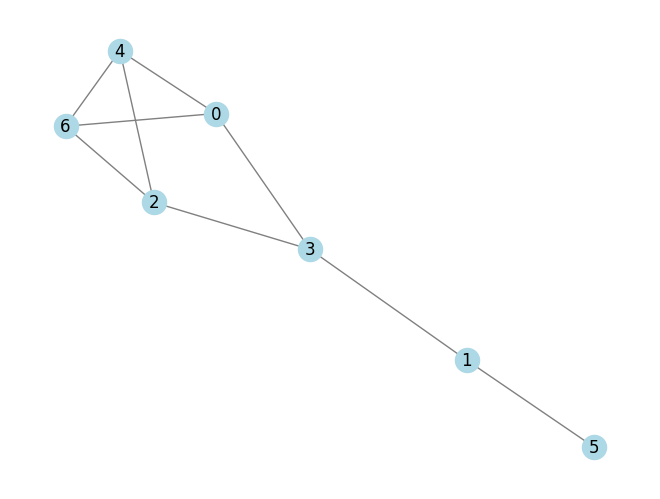

In [3]:
graph = Graph(n, k)


nx.draw(graph, with_labels=True, node_color='lightblue', edge_color='gray')
plt.show()

In [4]:
H_c, C_z = cost_H(d, graph, k)
H_m = mixer_H(d, n)
psi0 = init(d, n)

In [ ]:
def objective(params):
    g1, b1, g2, b2 = params

    P = penalty(d,n,b2)
    
    psi = U_C(g2, H_c) * U_M(b2, H_m) * U_C(g1, H_c) * U_M(b1, H_m) * psi0.unit()

    cost = 0
    for i in range(0, d):
        cost = (psi.dag() * tensor([fock(d,i)] * n) * tensor([fock(d,i).dag()] * n) * psi).real + cost
    return cost * (C_z + P)

# Number of parameters
p = 4

params = random(p)
result = minimize(objective, params, bounds = [(0, 1)] * p, method = 'SLSQP', options = {'maxiter':300, 'ftol':1e-10})
g1, b1, g2, b2 = result.x

print(result.fun)

psi_opt = U_C(g2, H_c) * U_M(b2, H_m) * U_C(g1, H_c) * U_M(b1, H_m) * psi0.unit()

def sample_measurements(circuit, shots= 2*d**n):
    state_vector = circuit.full().flatten()
    probabilities = np.abs(state_vector)**2
    probabilities = probabilities / np.sum(probabilities)
    outcomes = np.random.choice(len(probabilities), size=shots, p=probabilities)
    histogram = np.bincount(outcomes, minlength=len(probabilities))
    return np.arange(len(histogram)), histogram

state, prob = sample_measurements(psi_opt)

plt.figure(figsize=(10, 6))
plt.bar(state, prob, color='skyblue')
plt.xlabel("Computational Basis State Index")
plt.ylabel("Count")
plt.title("Measurement")
plt.show()

threshold = 0.99 * np.max(prob)
high_state_indices = state[prob >= threshold]
high_state_counts = prob[prob >= threshold]

In [ ]:
def int_to_base(num, base, width):
    """Convert an integer to a base-`base` string with at least `width` digits."""
    s = ""
    for _ in range(width):
        s = str(num % base) + s
        num //= base
    return s

high_state_str = [int_to_base(x, k, n) for x in high_state_indices]

for idx, s in zip(high_state_indices, high_state_str):
    print("Index : {}".format(s))

In [ ]:
chosen_state = high_state_str[-0]

# color list
color_list = ['red', 'green', 'blue', 'orange', 'purple', 'brown', 'pink', 'gray', 'olive', 'cyan']

nodes = list(graph.nodes())

# color filling
node_colors = []
for i, node in enumerate(nodes):
    digit = chosen_state[i]
    color = color_list[int(digit)]
    node_colors.append(color)


pos = nx.spring_layout(graph)
nx.draw(graph, pos, with_labels=True, node_color=node_colors, font_color='white')
plt.title("Graph colored by high state: {}".format(chosen_state))
plt.show()